In [2]:
import random
import math
import matplotlib.pyplot as plt
def generate_fake_heart_rate(n, base_bpm=72):
    data = []
    variation = 0
    phase = 0

    for i in range(n):
        # breathing-like slow oscillation
        phase += 0.1
        breathing = math.sin(phase) * 2

        # slow drift
        variation += random.uniform(-0.2, 0.2)
        variation = max(-2, min(2, variation))

        # sensor noise
        noise = random.uniform(-1.0, 1.0)

        bpm = base_bpm + breathing + variation + noise

        # occasional motion spike
        if random.randint(0, 60) == 0:
            bpm += random.randint(10, 25)

        data.append(round(bpm, 1))

    return data

def generate_anxiety_heart_rate(n, base_bpm=72):
    data = []
    variation = 0
    phase = 0

    for i in range(n):
        # faster breathing (anxiety)
        phase += 0.25
        breathing = math.sin(phase) * 4

        # unstable heart rate drift
        variation += random.uniform(-0.6, 0.6)
        variation = max(-3, min(10, variation))

        # high sensor jitter
        noise = random.uniform(-2.0, 2.0)

        bpm = base_bpm + breathing + variation + noise

        # frequent stress spikes
        if random.randint(0, 15) == 0:
            bpm += random.randint(8, 25)

        data.append(bpm)

    return data


In [3]:
hr = generate_anxiety_heart_rate(20)
print(hr)

[74.19816681109181, 73.58890108950159, 74.24313784173403, 76.9142783106469, 73.28111899614922, 75.04362489138549, 74.99325221939363, 74.79081078553199, 74.55910865833026, 72.50456970847627, 72.2049009686062, 71.90820377770764, 72.55737499822685, 71.07113162170343, 68.7328952078822, 69.28007013750312, 67.43166906967879, 68.69521686467682, 69.11597770989987, 69.28473668940087]


In [4]:
import numpy as np

def moving_average(data, window_size=5):
    data = np.array(data)
    return np.convolve(data, np.ones(window_size)/window_size, mode="valid")

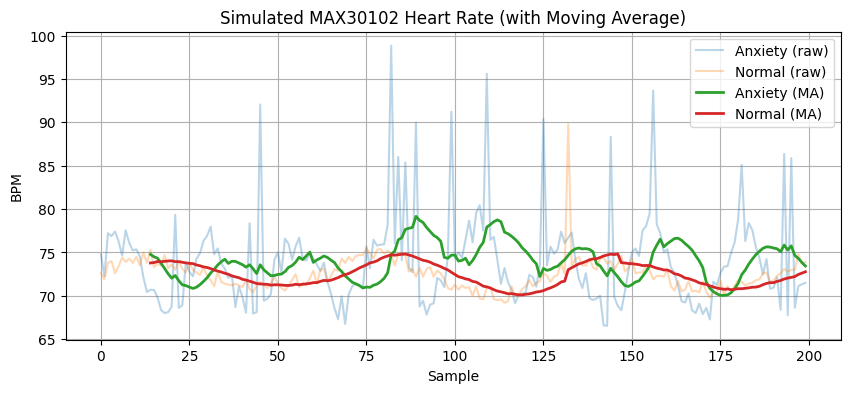

In [5]:
# -------- Generate Data --------
N = 200         # number of samples
anx_heart_rate = generate_anxiety_heart_rate(N)
normal_heart_rate = generate_fake_heart_rate(N)

window = 15  # try 5–10 for good smoothing

anx_ma = moving_average(anx_heart_rate, window)
norm_ma = moving_average(normal_heart_rate, window)

plt.figure(figsize=(10,4))

# Raw signals
plt.plot(anx_heart_rate, alpha=0.3, label="Anxiety (raw)")
plt.plot(normal_heart_rate, alpha=0.3, label="Normal (raw)")

# Smoothed signals
plt.plot(range(window-1, N), anx_ma, linewidth=2, label="Anxiety (MA)")
plt.plot(range(window-1, N), norm_ma, linewidth=2, label="Normal (MA)")

plt.title("Simulated MAX30102 Heart Rate (with Moving Average)")
plt.xlabel("Sample")
plt.ylabel("BPM")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
import numpy as np

# Convert to numpy arrays
anx = np.array(anx_ma)
norm = np.array(norm_ma)

# Compute absolute difference
diff = np.abs(anx - norm)

# Area between curves (Δt = 1 sample)
area = np.trapezoid(diff)/len(diff)

print("Area between curves:", area)


Area between curves: 2.4554620447882995


Area between curves: 4.47764818709621


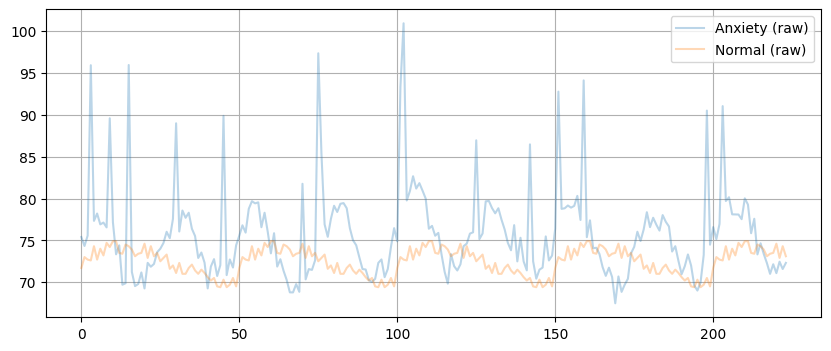

In [21]:
N1 = 50
N = 224

anx_heart_rate = generate_anxiety_heart_rate(N)
normal_heart_rate = generate_fake_heart_rate(N1)

# Repeat normal heart rate to match length of anx
normal_repeated = np.tile(normal_heart_rate, int(np.ceil(len(anx_heart_rate)/len(normal_heart_rate))))
normal_repeated = normal_repeated[:len(anx_heart_rate)]  # trim to exact size

diff = np.abs(np.array(anx_heart_rate) - np.array(normal_repeated))
area = np.trapezoid(diff) / len(diff)

print("Area between curves:", area)
plt.figure(figsize=(10,4))

# Raw signals
plt.plot(anx_heart_rate, alpha=0.3, label="Anxiety (raw)")
plt.plot(normal_repeated, alpha=0.3, label="Normal (raw)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
t_min = 5
t_max = 50
I_min = 80
I_max = 110
S_min = 60
S_max = 80

# t means time , I means intensity , S means size

import numpy as np

def scorechanger(t, I, S, area, threshold, lr):
    # Normalize
    t = (t - t_min) / (t_max - t_min)
    I = (I - I_min) / (I_max - I_min)
    S = (S - S_min) / (S_max - S_min)

    # Error signal
    error = area - threshold

    # Control law
    t -= lr * error
    I -= lr * error
    S += lr * error

    # Small noise (optional)
    noise = 0.01
    t += np.random.uniform(-noise, noise)
    I += np.random.uniform(-noise, noise)
    S += np.random.uniform(-noise, noise)

    # Clamp to [0,1]
    t = np.clip(t, 0, 1)
    I = np.clip(I, 0, 1)
    S = np.clip(S, 0, 1)

    # De-normalize
    t = int(t * (t_max - t_min) + t_min)
    I = int(I * (I_max - I_min) + I_min)
    S = int(S * (S_max - S_min) + S_min)

    return t, I, S


In [ ]:
t = 10
I = 90
S = 70
Threshold = 1
lr = 0.1
area = 22
scorechanger(t,I,S,area,Threshold,lr)

(5, 80, 80)

In [ ]:
np.random.uniform(-0.2,0.2)

0.004795257905616791

In [ ]:
import numpy as np

X = np.random.randn(4,3)
X

array([[-0.35652467,  1.12998533, -0.63612865],
       [-0.92243624, -1.27703301,  0.47802038],
       [ 2.69797966,  0.97280799,  0.33882977],
       [ 0.85367942, -1.98421554,  0.46981775]])

In [ ]:
import numpy as np

X = np.random.randn(4,3)
y = np.random.randn(4,1)

In [ ]:
# X -> (4,3)
# y -> (4,1)

x1 = X[:,0:1]
x2 = X[:,1:2]
x3 = X[:,2:3]

Phi = np.hstack([
    x1,
    x2,
    x3,
    x1 * x2,
    x2 * x3,
    x3 * x1
])   # shape (B, 6)

# add bias
Phi_aug = np.hstack([Phi, np.ones((Phi.shape[0], 1))])

theta = np.linalg.lstsq(Phi_aug, y, rcond=None)[0]

w = theta[:-1]
b = theta[-1]

w,b

(array([[-1.07466983],
        [-0.4875418 ],
        [-0.82357158],
        [ 1.63938485],
        [-0.79051836],
        [ 0.11125816]]),
 array([0.5992008]))